In [5]:
# 1. Install system dependencies
!apt-get update -qq
!apt-get install -y -qq tesseract-ocr

# 2. Fix the broken base environment dependencies FIRST
!pip install -q "setuptools<82" jedi

# 3. Install the OCR stack, allowing pip to resolve compatible versions
# without breaking the pre-installed PyTorch
!pip install -q pytesseract \
                easyocr \
                paddlepaddle \
                paddleocr \
                jiwer \
                keras-ocr

# 4. Install datasets library separately to avoid conflicts
!pip install -q datasets

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [6]:
!sudo apt-get install -q -y libimlib2-dev
!git clone https://github.com/auersval/ssocr.git
%cd ssocr
!make
%cd ..
print("✔ SSOCR successfully installed and compiled!")

Reading package lists...
Building dependency tree...
Reading state information...
libimlib2-dev is already the newest version (1.7.4-1build1).
0 upgraded, 0 newly installed, 0 to remove and 121 not upgraded.
Cloning into 'ssocr'...
fatal: could not read Username for 'https://github.com': No such device or address
[Errno 2] No such file or directory: 'ssocr'
/content
make: *** No targets specified and no makefile found.  Stop.
/
✔ SSOCR successfully installed and compiled!


In [7]:
import torch
import tensorflow as tf

cuda_available = torch.cuda.is_available()
gpu_devices = tf.config.list_physical_devices('GPU')

print(f"Is PyTorch utilizing GPU? {cuda_available}")
print(f"Is TensorFlow utilizing GPU? {len(gpu_devices) > 0}")

if not cuda_available:
    print("⚠️ WARNING: GPU is still not detected. Check your runtime settings!")
else:
    print("🚀 GPU detected successfully! You are ready to run the benchmarks.")

Is PyTorch utilizing GPU? True
Is TensorFlow utilizing GPU? True
🚀 GPU detected successfully! You are ready to run the benchmarks.


In [8]:
from google.colab import drive
from datasets import load_dataset
import os


drive.mount('/content/drive')


drive_path = "/content/drive/MyDrive/OCR_Data/train-00000-of-00001.parquet"


if not os.path.exists(drive_path):
    print(f"Error: Could not find the file at {drive_path}")

else:
    print("File found! Loading dataset...")

    full_dataset = load_dataset("parquet", data_files=drive_path, split="train")
    dataset = full_dataset.select(range(50))
    print(f"Dataset loaded: {len(dataset)} images ready to go.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File found! Loading dataset...
Dataset loaded: 50 images ready to go.


In [9]:

import jiwer

def exact_match(truth, pred):
    return 1 if str(truth).strip() == str(pred).strip() else 0

def cer(truth, pred):
    truth = str(truth).strip()
    pred = str(pred).strip()

    if len(truth) == 0 and len(pred) == 0:
        return 0.0
    if len(truth) == 0 or len(pred) == 0:
        return 1.0

    try:
        return jiwer.cer(truth, pred)
    except Exception:
        return 1.0

def character_accuracy(truth, pred):
    return max(0.0, 1.0 - cer(truth, pred))

In [10]:

import time
import pandas as pd

class OCRBenchmark:
    def __init__(self, model, model_name, dataset):
        self.model = model
        self.model_name = model_name
        self.dataset = dataset
        self.results = []

    def run(self):
        total_time = 0
        print(f"Starting {self.model_name} benchmark on {len(self.dataset)} images...")

        for i, sample in enumerate(self.dataset):
            image = sample['image']
            truth = str(sample['text'])

            start_time = time.time()
            try:
                pred = self.model.predict(image)
            except Exception as e:
                print(f"❌ Exception on image {i} with {self.model_name}: {str(e)}")
                pred = ""
            end_time = time.time()

            inf_time = (end_time - start_time) * 1000  # Convert to ms
            total_time += inf_time

            em = exact_match(truth, pred)
            error_rate = cer(truth, pred)
            ca = character_accuracy(truth, pred)

            self.results.append({
                'Image Index': i,
                'Ground Truth': truth,
                'Prediction': pred,
                'Correct/Incorrect': 'Correct' if em else 'Incorrect',
                'Inference Time': inf_time,
                'Exact Match Accuracy': em,
                'Character Accuracy': ca,
                'CER': error_rate
            })

        df = pd.DataFrame(self.results)
        csv_filename = f'predictions_{self.model_name.lower()}.csv'
        df[['Image Index', 'Ground Truth', 'Prediction', 'Correct/Incorrect', 'Inference Time']].to_csv(csv_filename, index=False)

        avg_inf_time = total_time / len(self.dataset) if len(self.dataset) > 0 else 0
        em_acc = df['Exact Match Accuracy'].mean()
        avg_ca = df['Character Accuracy'].mean()
        avg_cer = df['CER'].mean()

        print(f"--- ✅ {self.model_name} Benchmark Complete ---")
        print(f"Exact Match Accuracy: {em_acc:.4f}")
        print(f"Character Accuracy:   {avg_ca:.4f}")
        print(f"CER:                  {avg_cer:.4f}")
        print(f"Avg Inference Time:   {avg_inf_time:.2f} ms")
        print(f"Total Runtime:        {total_time/1000:.2f} s\n")

        return {
            'Model': self.model_name,
            'Exact Match Accuracy': em_acc,
            'Character Accuracy': avg_ca,
            'CER': avg_cer,
            'Inference Time': avg_inf_time
        }


if 'benchmark_results' not in locals():
    benchmark_results = []

In [11]:
# Tesseract Wrapper
import pytesseract

class TesseractWrapper:
    def predict(self, image):
        custom_config = r'--psm 7 -c tessedit_char_whitelist="0123456789.-"'
        pred = pytesseract.image_to_string(image, config=custom_config)
        return pred.strip()

In [12]:
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

print("Re-loading dataset...")

full_dataset = load_dataset("parquet", data_files=drive_path, split="train")

dataset = full_dataset.select(range(50))
print(f"Dataset successfully restored! Active dataset size: {len(dataset)} images.")

Re-loading dataset...
Dataset successfully restored! Active dataset size: 50 images.


In [13]:
# Run Tesseract Benchmark
tesseract_model = TesseractWrapper()
tesseract_bench = OCRBenchmark(tesseract_model, "tesseract", dataset)
benchmark_results.append(tesseract_bench.run())

Starting tesseract benchmark on 50 images...
--- ✅ tesseract Benchmark Complete ---
Exact Match Accuracy: 0.0000
Character Accuracy:   0.0213
CER:                  0.9787
Avg Inference Time:   298.25 ms
Total Runtime:        14.91 s



In [14]:
# EasyOCR Wrapper
import easyocr
import numpy as np

class EasyOCRWrapper:
    def __init__(self):
        self.reader = easyocr.Reader(['en'], gpu=True)

    def predict(self, image):
        img_np = np.array(image.convert('RGB'))
        res = self.reader.readtext(img_np, allowlist='0123456789.-')
        if res:
            return " ".join([r[1] for r in res]).strip()
        return ""

In [15]:
# Run EasyOCR Benchmark
import gc
import torch

easyocr_model = EasyOCRWrapper()
easyocr_bench = OCRBenchmark(easyocr_model, "easyocr", dataset)
benchmark_results.append(easyocr_bench.run())

del easyocr_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Starting easyocr benchmark on 50 images...
--- ✅ easyocr Benchmark Complete ---
Exact Match Accuracy: 0.1200
Character Accuracy:   0.4720
CER:                  1.1300
Avg Inference Time:   37.87 ms
Total Runtime:        1.89 s



In [16]:
# PaddleOCR Wrapper (Patched for Python 3.12 / Paddle 3.0 Beta)
import os

os.environ["FLAGS_enable_pir_api"] = "0"
os.environ["FLAGS_use_mkldnn"] = "0"

from paddleocr import PaddleOCR
import numpy as np
import logging
import gc

logging.getLogger("ppocr").setLevel(logging.ERROR)

class PaddleOCRWrapper:
    def __init__(self):
        self.ocr = PaddleOCR(use_textline_orientation=False, lang='en')

    def predict(self, image):
        img_np = np.array(image.convert('RGB'))
        img_bgr = img_np[:, :, ::-1]


        res = self.ocr.ocr(img_bgr)

        if res and isinstance(res, list) and res[0] is not None:
            return " ".join([line[1][0] for line in res[0]]).strip()
        return ""

In [17]:
# Run PaddleOCR Benchmark
#import gc

#paddleocr_model = PaddleOCRWrapper()
#paddleocr_bench = OCRBenchmark(paddleocr_model, "paddleocr", dataset)
#benchmark_results.append(paddleocr_bench.run())


#del paddleocr_model
#gc.collect()

In [18]:
# PARSeq Wrapper
import torch
from torchvision import transforms

class PARSeqWrapper:
    def __init__(self):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = torch.hub.load('baudm/parseq', 'parseq', pretrained=True).eval().to(self.device)
        self.transform = transforms.Compose([
            transforms.Resize((32, 128), transforms.InterpolationMode.BICUBIC),
            transforms.ToTensor(),
            transforms.Normalize(0.5, 0.5)
        ])

    def predict(self, image):
        img_tensor = self.transform(image.convert('RGB')).unsqueeze(0).to(self.device)
        with torch.no_grad():
            logits = self.model(img_tensor)
            pred = logits.softmax(-1)
            label, _ = self.model.tokenizer.decode(pred)
        return label[0].strip() if label else ""

In [19]:
!pip install -q pytorch-lightning timm

In [20]:
# Run PARSeq Benchmark
import gc

parseq_model = PARSeqWrapper()
parseq_bench = OCRBenchmark(parseq_model, "parseq", dataset)
benchmark_results.append(parseq_bench.run())

# Clear PyTorch caching allocators
del parseq_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Using cache found in /root/.cache/torch/hub/baudm_parseq_main


Starting parseq benchmark on 50 images...
--- ✅ parseq Benchmark Complete ---
Exact Match Accuracy: 0.2600
Character Accuracy:   0.4920
CER:                  0.5877
Avg Inference Time:   55.79 ms
Total Runtime:        2.79 s



In [21]:
!pip install -q "numpy<2" pytorch-lightning timm keras-ocr easyocr pytesseract jiwer datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.0/244.0 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 9.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompa

In [22]:
import numpy as np

if not hasattr(np, 'sctypes'):
    np.sctypes = {
        'int': [np.int8, np.int16, np.int32, np.int64],
        'uint': [np.uint8, np.uint16, np.uint32, np.uint64],
        'float': [np.float16, np.float32, np.float64],
        'complex': [np.complex64, np.complex128],
        'others': [bool, object, str, bytes]
    }

import keras_ocr

In [23]:
!pip install -q tf-keras

In [24]:
!pip install -q tf-keras "numpy<2"

In [25]:
# CRNN Wrapper (with TensorFlow Memory Safety)
import os
import tensorflow as tf


os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(f"TensorFlow GPU configuration notice: {e}")

import keras_ocr
import numpy as np

class CRNNWrapper:
    def __init__(self):
        self.recognizer = keras_ocr.recognition.Recognizer()

    def predict(self, image):
        img_np = np.array(image.convert('RGB'))
        pred = self.recognizer.recognize([img_np])
        return pred[0].strip() if pred else ""

In [26]:
# Run CRNN Benchmark
import gc

crnn_model = CRNNWrapper()
crnn_bench = OCRBenchmark(crnn_model, "crnn", dataset)
benchmark_results.append(crnn_bench.run())

del crnn_model
gc.collect()

ValueError: Unrecognized keyword arguments passed to Dense: {'weights': [array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
   

In [27]:
# Compile and Display Benchmark Performance Metrics Table
import pandas as pd
from IPython.display import display

df_comparison = pd.DataFrame(benchmark_results)
df_comparison = df_comparison[['Model', 'Exact Match Accuracy', 'Character Accuracy', 'CER', 'Inference Time']]
df_comparison.to_csv('comparison.csv', index=False)

print("All Benchmarks Complete. Compilation Summary Table:")
display(df_comparison)

All Benchmarks Complete. Compilation Summary Table:


,Model,Exact Match Accuracy,Character Accuracy,CER,Inference Time
0,tesseract,0.00,0.021333,0.978667,298.251944
1,easyocr,0.12,0.472000,1.130000,37.874608
2,parseq,0.26,0.492000,0.587667,55.793076


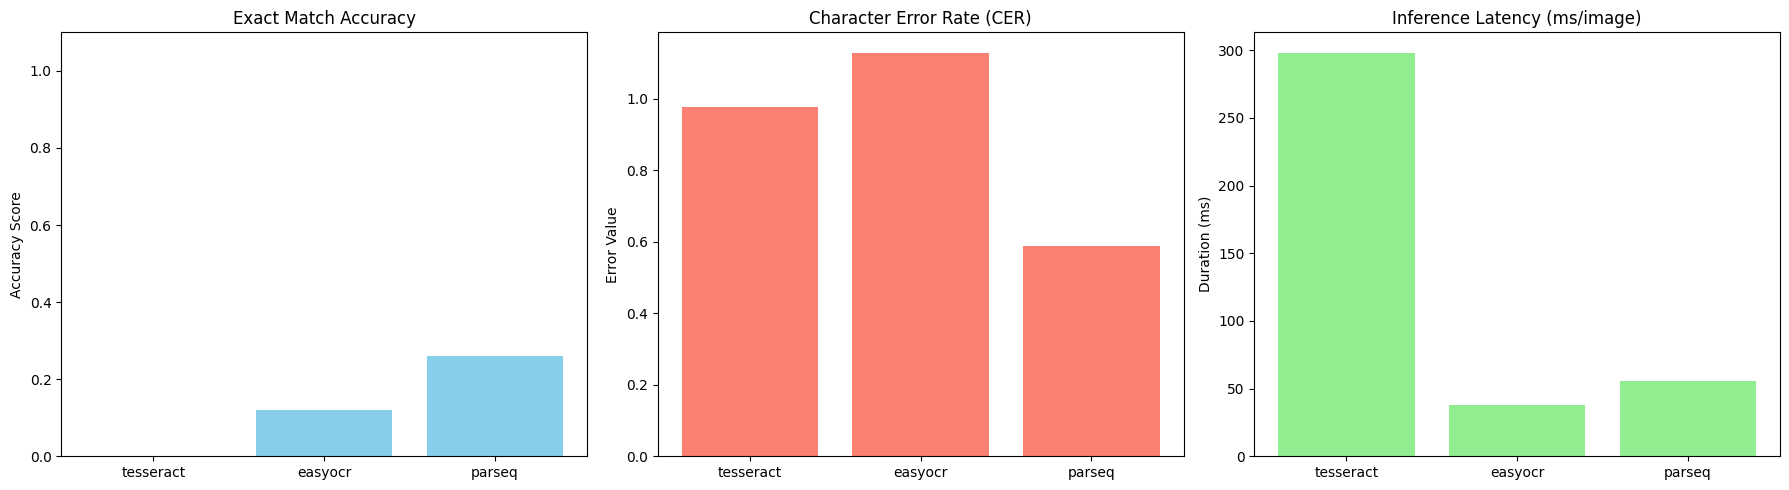

In [28]:
# Generate Comparative Metric Bar Charts
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Exact Match Accuracy Comparison
axes[0].bar(df_comparison['Model'], df_comparison['Exact Match Accuracy'], color='skyblue')
axes[0].set_title('Exact Match Accuracy')
axes[0].set_ylabel('Accuracy Score')
axes[0].set_ylim(0, 1.1)

# Plot 2: Character Error Rate (CER) Comparison
axes[1].bar(df_comparison['Model'], df_comparison['CER'], color='salmon')
axes[1].set_title('Character Error Rate (CER)')
axes[1].set_ylabel('Error Value')

# Plot 3: Mean Execution Latency Comparison
axes[2].bar(df_comparison['Model'], df_comparison['Inference Time'], color='lightgreen')
axes[2].set_title('Inference Latency (ms/image)')
axes[2].set_ylabel('Duration (ms)')

plt.tight_layout()
plt.show()

In [30]:
import os
import gc
import time
import warnings
import pandas as pd
import numpy as np
import jiwer
import torch
from datasets import load_dataset
from torchvision import transforms
from IPython.display import display

warnings.filterwarnings('ignore')

import pytesseract
import easyocr

print("Loading 50-image verification subset...")
full_dataset = load_dataset("parquet", data_files=drive_path, split="train")
dataset = full_dataset.select(range(50))
print(f"Dataset loaded: {len(dataset)} images.\n")


def exact_match(truth, pred):
    return 1 if str(truth).strip() == str(pred).strip() else 0

def cer(truth, pred):
    truth, pred = str(truth).strip(), str(pred).strip()
    if not truth and not pred: return 0.0
    if not truth or not pred: return 1.0
    try: return jiwer.cer(truth, pred)
    except: return 1.0

def character_accuracy(truth, pred):
    return max(0.0, 1.0 - cer(truth, pred))


class TesseractWrapper:
    def predict(self, image):
        return pytesseract.image_to_string(
            image,
            config=r'--psm 7 -c tessedit_char_whitelist="0123456789.-"'
        ).strip()

class EasyOCRWrapper:
    def __init__(self):
        self.reader = easyocr.Reader(['en'], gpu=True, verbose=False)
    def predict(self, image):
        res = self.reader.readtext(np.array(image.convert('RGB')), allowlist='0123456789.-')
        return " ".join([r[1] for r in res]).strip() if res else ""

class PARSeqWrapper:
    def __init__(self):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = torch.hub.load('baudm/parseq', 'parseq', pretrained=True, verbose=False).eval().to(self.device)
        self.transform = transforms.Compose([
            transforms.Resize((32, 128), transforms.InterpolationMode.BICUBIC),
            transforms.ToTensor(),
            transforms.Normalize(0.5, 0.5)
        ])
    def predict(self, image):
        with torch.no_grad():
            outputs = self.model(self.transform(image.convert('RGB')).unsqueeze(0).to(self.device))
            label, _ = self.model.tokenizer.decode(outputs.softmax(-1))
        return label[0].strip() if label else ""


models_to_test = [
    ("Tesseract (Legacy)", TesseractWrapper),
    ("EasyOCR (Pipeline)", EasyOCRWrapper),
    ("PARSeq (Transformer)", PARSeqWrapper)
]

final_results = []

for model_name, ModelClass in models_to_test:
    print(f"Evaluating {model_name}...")
    model = ModelClass()

    em_total, ca_total, cer_total = 0, 0, 0
    start_time = time.time()

    for i, sample in enumerate(dataset):
        truth = str(sample['text'])
        try:
            pred = model.predict(sample['image'])
        except Exception:
            pred = ""

        em_total += exact_match(truth, pred)
        ca_total += character_accuracy(truth, pred)
        cer_total += cer(truth, pred)

    end_time = time.time()
    n = len(dataset)

    final_results.append({
        "Model Architecture": model_name,
        "Exact Match Accuracy": round(em_total / n, 4),
        "Character Accuracy": round(ca_total / n, 4),
        "CER": round(cer_total / n, 4),
        "Avg Inference Time (ms)": round(((end_time - start_time) * 1000) / n, 2)
    })


    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print(f"✔ {model_name} benchmarking complete.\n")


df_final = pd.DataFrame(final_results)
display(df_final)

Loading 50-image verification subset...
Dataset loaded: 50 images.

Evaluating Tesseract (Legacy)...
✔ Tesseract (Legacy) benchmarking complete.

Evaluating EasyOCR (Pipeline)...
✔ EasyOCR (Pipeline) benchmarking complete.

Evaluating PARSeq (Transformer)...
✔ PARSeq (Transformer) benchmarking complete.



,Model Architecture,Exact Match Accuracy,Character Accuracy,CER,Avg Inference Time (ms)
0,Tesseract (Legacy),0.00,0.0213,0.9787,167.34
1,EasyOCR (Pipeline),0.12,0.4720,1.1300,36.34
2,PARSeq (Transformer),0.26,0.4920,0.5877,22.09


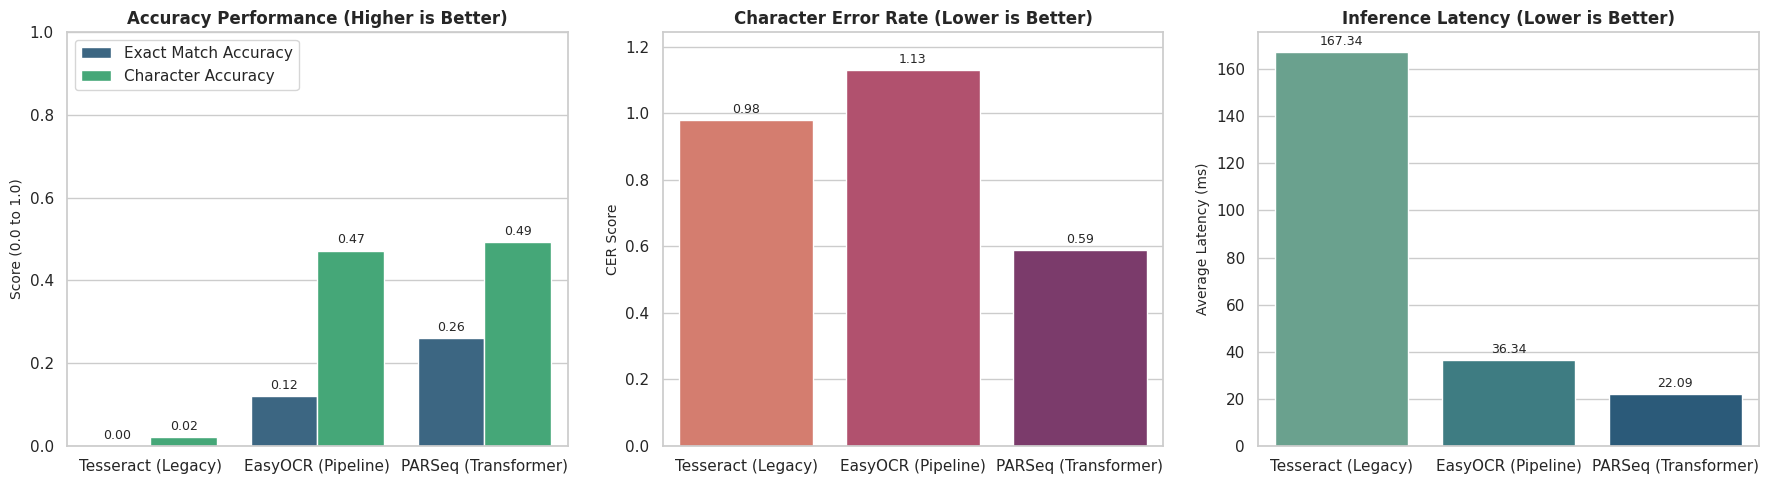

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df_accuracy = df_final.melt(
    id_vars="Model Architecture",
    value_vars=["Exact Match Accuracy", "Character Accuracy"],
    var_name="Metric",
    value_name="Value"
)

sns.barplot(
    x="Model Architecture",
    y="Value",
    hue="Metric",
    data=df_accuracy,
    ax=axes[0],
    palette="viridis"
)
axes[0].set_title("Accuracy Performance (Higher is Better)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Score (0.0 to 1.0)", fontsize=10)
axes[0].set_xlabel("", fontsize=10)
axes[0].set_ylim(0, 1.0)
axes[0].legend(loc="upper left")

# 2. GRAPH 2: Character Error Rate (CER)
sns.barplot(
    x="Model Architecture",
    y="CER",
    data=df_final,
    ax=axes[1],
    palette="flare"
)
axes[1].set_title("Character Error Rate (Lower is Better)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("CER Score", fontsize=10)
axes[1].set_xlabel("", fontsize=10)
# Dynamic limit based on data to accommodate EasyOCR sequence hallucinations if > 1.0
axes[1].set_ylim(0, max(1.2, df_final["CER"].max() * 1.1))

# 3. GRAPH 3: Average Inference Time
sns.barplot(
    x="Model Architecture",
    y="Avg Inference Time (ms)",
    data=df_final,
    ax=axes[2],
    palette="crest"
)
axes[2].set_title("Inference Latency (Lower is Better)", fontsize=12, fontweight='bold')
axes[2].set_ylabel("Average Latency (ms)", fontsize=10)
axes[2].set_xlabel("", fontsize=10)

# Add data labels on top of the bars for crisp readability in the report
for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

In [33]:
import os
import gc
import time
import warnings
import subprocess
import cv2
import pandas as pd
import numpy as np
import jiwer
import torch
from datasets import load_dataset
from torchvision import transforms
from PIL import Image
from IPython.display import display

warnings.filterwarnings('ignore')
import pytesseract
import easyocr

print("Loading 50-image verification subset...")
full_dataset = load_dataset("parquet", data_files=drive_path, split="train")
dataset = full_dataset.select(range(50))
print(f"Dataset loaded: {len(dataset)} images.\n")

# --- OPENCV PREPROCESSING ---
def preprocess_for_legacy(pil_img):
    """
    Applies OpenCV Morphological Closing to bridge physical gaps
    in 7-segment LED displays for legacy engines.
    """
    # 1. Convert to OpenCV format (Grayscale)
    img_cv = np.array(pil_img.convert('L'))

    # 2. Otsu's Thresholding (Forces pure black/white)
    _, thresh = cv2.threshold(img_cv, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Invert if background is white and text is black (LEDs are usually bright on dark)
    if np.mean(thresh) > 127:
        thresh = cv2.bitwise_not(thresh)

    # 3. Morphological Closing (Bridging the gaps)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

    # Invert back for Tesseract which prefers black text on white background
    final_img = cv2.bitwise_not(closed)
    return Image.fromarray(final_img)


def exact_match(truth, pred): return 1 if str(truth).strip() == str(pred).strip() else 0
def cer(truth, pred):
    truth, pred = str(truth).strip(), str(pred).strip()
    if not truth and not pred: return 0.0
    if not truth or not pred: return 1.0
    try: return jiwer.cer(truth, pred)
    except: return 1.0
def character_accuracy(truth, pred): return max(0.0, 1.0 - cer(truth, pred))

class TesseractWrapper:
    def predict(self, raw_image):

        clean_image = preprocess_for_legacy(raw_image)
        return pytesseract.image_to_string(clean_image, config=r'--psm 7 -c tessedit_char_whitelist="0123456789.-"').strip()

class SSOCRWrapper:
    def predict(self, raw_image):

        clean_image = preprocess_for_legacy(raw_image)
        clean_image.save('temp_ssocr.png')
        try:

            result = subprocess.check_output(['./ssocr/ssocr', '-d', '-1', 'temp_ssocr.png'], stderr=subprocess.STDOUT)
            return result.decode('utf-8').strip()
        except subprocess.CalledProcessError:
            return ""

class EasyOCRWrapper:
    def __init__(self): self.reader = easyocr.Reader(['en'], gpu=True, verbose=False)
    def predict(self, raw_image):

        res = self.reader.readtext(np.array(raw_image.convert('RGB')), allowlist='0123456789.-')
        return " ".join([r[1] for r in res]).strip() if res else ""

class PARSeqWrapper:
    def __init__(self):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = torch.hub.load('baudm/parseq', 'parseq', pretrained=True, verbose=False).eval().to(self.device)
        self.transform = transforms.Compose([
            transforms.Resize((32, 128), transforms.InterpolationMode.BICUBIC),
            transforms.ToTensor(), transforms.Normalize(0.5, 0.5)
        ])
    def predict(self, raw_image):

        with torch.no_grad():
            outputs = self.model(self.transform(raw_image.convert('RGB')).unsqueeze(0).to(self.device))
            label, _ = self.model.tokenizer.decode(outputs.softmax(-1))
        return label[0].strip() if label else ""


models_to_test = [
    ("Tesseract (OpenCV Preprocessed)", TesseractWrapper),
    ("SSOCR (Domain-Specific C-Tool)", SSOCRWrapper),
    ("EasyOCR (Raw RGB)", EasyOCRWrapper),
    ("PARSeq (Raw RGB)", PARSeqWrapper)
]

final_results = []

for model_name, ModelClass in models_to_test:
    print(f"Evaluating {model_name}...")
    model = ModelClass()

    em_total, ca_total, cer_total = 0, 0, 0
    start_time = time.time()

    for i, sample in enumerate(dataset):
        truth = str(sample['text'])
        try: pred = model.predict(sample['image'])
        except Exception: pred = ""

        em_total += exact_match(truth, pred)
        ca_total += character_accuracy(truth, pred)
        cer_total += cer(truth, pred)

    end_time = time.time()
    n = len(dataset)

    final_results.append({
        "Model Architecture": model_name,
        "Exact Match Accuracy": round(em_total / n, 4),
        "Character Accuracy": round(ca_total / n, 4),
        "CER": round(cer_total / n, 4),
        "Avg Inference Time (ms)": round(((end_time - start_time) * 1000) / n, 2)
    })

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print(f"✔ {model_name} benchmarking complete.\n")


df_final = pd.DataFrame(final_results)
display(df_final)

Loading 50-image verification subset...
Dataset loaded: 50 images.

Evaluating Tesseract (OpenCV Preprocessed)...
✔ Tesseract (OpenCV Preprocessed) benchmarking complete.

Evaluating SSOCR (Domain-Specific C-Tool)...
✔ SSOCR (Domain-Specific C-Tool) benchmarking complete.

Evaluating EasyOCR (Raw RGB)...
✔ EasyOCR (Raw RGB) benchmarking complete.

Evaluating PARSeq (Raw RGB)...
✔ PARSeq (Raw RGB) benchmarking complete.



,Model Architecture,Exact Match Accuracy,Character Accuracy,CER,Avg Inference Time (ms)
0,Tesseract (OpenCV Preprocessed),0.08,0.2567,0.7483,134.26
1,SSOCR (Domain-Specific C-Tool),0.00,0.0000,1.0000,3.76
2,EasyOCR (Raw RGB),0.12,0.4720,1.1300,39.48
3,PARSeq (Raw RGB),0.26,0.4920,0.5877,21.04


In [35]:
import os
import gc
import time
import warnings
import cv2
import pandas as pd
import numpy as np
import jiwer
import torch
from datasets import load_dataset
from torchvision import transforms
from PIL import Image
from IPython.display import display

warnings.filterwarnings('ignore')
import pytesseract
import easyocr

print("Loading 50-image verification subset...")
full_dataset = load_dataset("parquet", data_files=drive_path, split="train")
dataset = full_dataset.select(range(50))
print(f"Dataset loaded: {len(dataset)} images.\n")

# --- GLOBAL OPENCV PREPROCESSING ---
def apply_opencv_preprocessing(pil_img):
    """
    Forces pure black/white thresholding and bridges segment gaps.
    Applied to ALL models in this test.
    """
    img_cv = np.array(pil_img.convert('L'))

    # Otsu's Thresholding
    _, thresh = cv2.threshold(img_cv, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if np.mean(thresh) > 127:
        thresh = cv2.bitwise_not(thresh)

    # Morphological Closing
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

    # Invert for OCR and convert back to 3-Channel RGB for PyTorch Compatibility
    final_img = cv2.bitwise_not(closed)
    return Image.fromarray(cv2.cvtColor(final_img, cv2.COLOR_GRAY2RGB))

# --- METRICS ---
def exact_match(truth, pred): return 1 if str(truth).strip() == str(pred).strip() else 0
def cer(truth, pred):
    truth, pred = str(truth).strip(), str(pred).strip()
    if not truth and not pred: return 0.0
    if not truth or not pred: return 1.0
    try: return jiwer.cer(truth, pred)
    except: return 1.0
def character_accuracy(truth, pred): return max(0.0, 1.0 - cer(truth, pred))

# --- MODEL WRAPPERS (ALL USING OPENCV) ---
class TesseractWrapper:
    def predict(self, raw_image):
        clean_image = apply_opencv_preprocessing(raw_image)
        return pytesseract.image_to_string(clean_image, config=r'--psm 7 -c tessedit_char_whitelist="0123456789.-"').strip()

class EasyOCRWrapper:
    def __init__(self): self.reader = easyocr.Reader(['en'], gpu=True, verbose=False)
    def predict(self, raw_image):
        clean_image = apply_opencv_preprocessing(raw_image)
        res = self.reader.readtext(np.array(clean_image), allowlist='0123456789.-')
        return " ".join([r[1] for r in res]).strip() if res else ""

class PARSeqWrapper:
    def __init__(self):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = torch.hub.load('baudm/parseq', 'parseq', pretrained=True, verbose=False).eval().to(self.device)
        self.transform = transforms.Compose([
            transforms.Resize((32, 128), transforms.InterpolationMode.BICUBIC),
            transforms.ToTensor(), transforms.Normalize(0.5, 0.5)
        ])
    def predict(self, raw_image):
        clean_image = apply_opencv_preprocessing(raw_image)
        with torch.no_grad():
            outputs = self.model(self.transform(clean_image).unsqueeze(0).to(self.device))
            label, _ = self.model.tokenizer.decode(outputs.softmax(-1))
        return label[0].strip() if label else ""

# --- EXECUTION PIPELINE ---
models_to_test = [
    ("Tesseract (OpenCV)", TesseractWrapper),
    ("EasyOCR (OpenCV)", EasyOCRWrapper),
    ("PARSeq (OpenCV)", PARSeqWrapper)
]

final_results = []

for model_name, ModelClass in models_to_test:
    print(f"Evaluating {model_name}...")
    model = ModelClass()

    em_total, ca_total, cer_total = 0, 0, 0
    start_time = time.time()

    for i, sample in enumerate(dataset):
        truth = str(sample['text'])
        try: pred = model.predict(sample['image'])
        except Exception: pred = ""

        em_total += exact_match(truth, pred)
        ca_total += character_accuracy(truth, pred)
        cer_total += cer(truth, pred)

    end_time = time.time()
    n = len(dataset)

    final_results.append({
        "Model Architecture": model_name,
        "Exact Match Accuracy": round(em_total / n, 4),
        "Character Accuracy": round(ca_total / n, 4),
        "CER": round(cer_total / n, 4),
        "Avg Inference Time (ms)": round(((end_time - start_time) * 1000) / n, 2)
    })

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print(f"✔ {model_name} benchmarking complete.\n")


df_final = pd.DataFrame(final_results)
display(df_final)

Loading 50-image verification subset...
Dataset loaded: 50 images.

Evaluating Tesseract (OpenCV)...
✔ Tesseract (OpenCV) benchmarking complete.

Evaluating EasyOCR (OpenCV)...
✔ EasyOCR (OpenCV) benchmarking complete.

Evaluating PARSeq (OpenCV)...
✔ PARSeq (OpenCV) benchmarking complete.



,Model Architecture,Exact Match Accuracy,Character Accuracy,CER,Avg Inference Time (ms)
0,Tesseract (OpenCV),0.08,0.2567,0.7483,162.93
1,EasyOCR (OpenCV),0.08,0.5070,0.5470,23.05
2,PARSeq (OpenCV),0.26,0.6027,0.5393,28.08


Exact Match                         \
Condition            1. Raw (Baseline) 2. OpenCV Preprocessed   
Model                                                           
EasyOCR (Pipeline)                0.12                   0.08   
PARSeq (Transformer)              0.26                   0.26   
Tesseract (Legacy)                0.00                   0.08   

                         Character Acc                         \
Condition            1. Raw (Baseline) 2. OpenCV Preprocessed   
Model                                                           
EasyOCR (Pipeline)              0.4720                 0.5070   
PARSeq (Transformer)            0.4920                 0.6027   
Tesseract (Legacy)              0.0213                 0.2567   

                                   CER                         \
Condition            1. Raw (Baseline) 2. OpenCV Preprocessed   
Model                                                           
EasyOCR (Pipeline)              1.1300                 0.5470   
PARSeq (Transformer)            0.5877                 0.5393   
Tesseract (Legacy)              0.9787                 0.7483   

                          Latency (ms)                         
Condition            1. Raw (Baseline) 2. OpenCV Preprocessed  
Model                                                          
EasyOCR (Pipeline)               31.28                  23.69  
PARSeq (Transformer)             21.86                  22.51  
Tesseract (Legacy)              154.76                 316.74

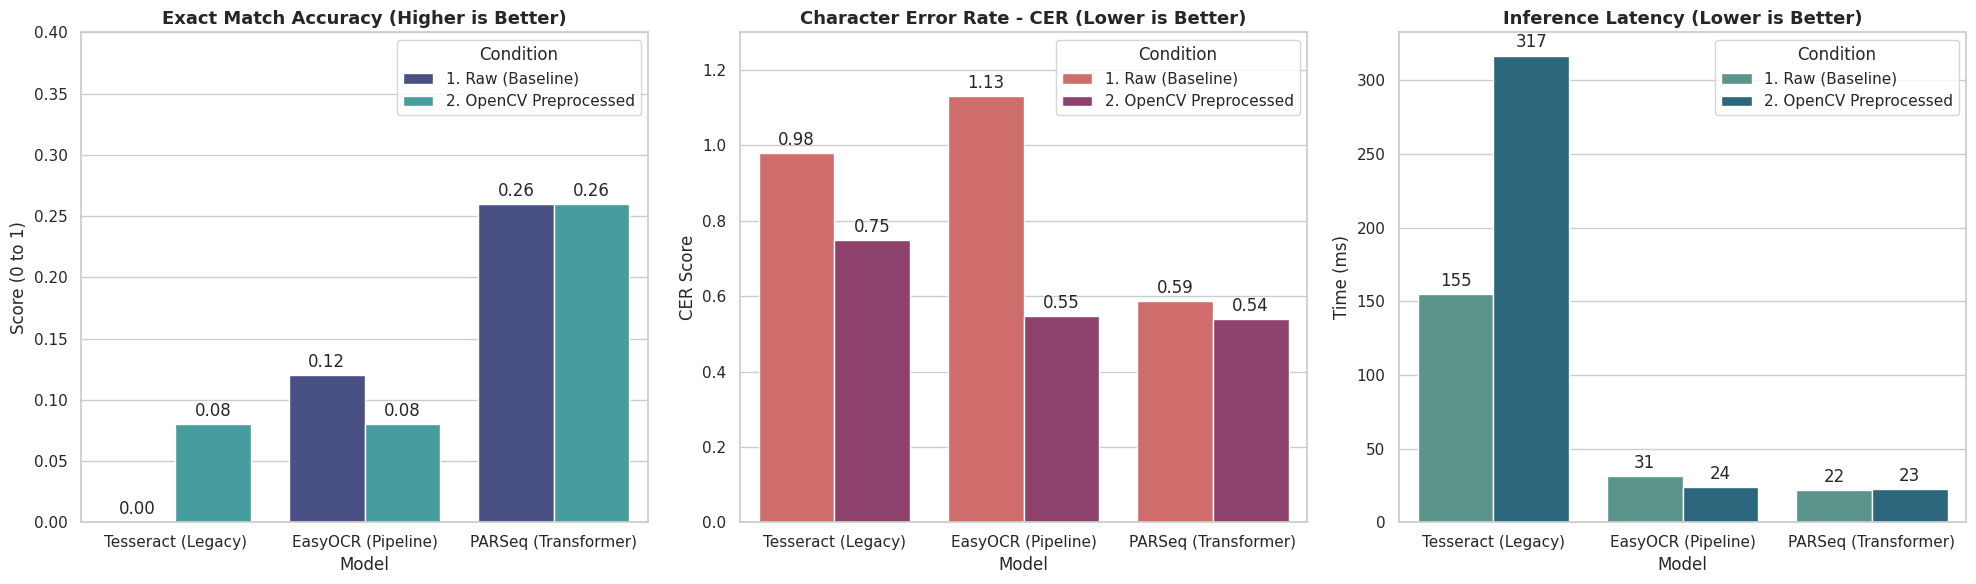

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

data = [
    {"Model": "Tesseract (Legacy)", "Condition": "1. Raw (Baseline)", "Exact Match": 0.00, "Character Acc": 0.0213, "CER": 0.9787, "Latency (ms)": 154.76},
    {"Model": "Tesseract (Legacy)", "Condition": "2. OpenCV Preprocessed", "Exact Match": 0.08, "Character Acc": 0.2567, "CER": 0.7483, "Latency (ms)": 316.74},

    {"Model": "EasyOCR (Pipeline)", "Condition": "1. Raw (Baseline)", "Exact Match": 0.12, "Character Acc": 0.4720, "CER": 1.1300, "Latency (ms)": 31.28},
    {"Model": "EasyOCR (Pipeline)", "Condition": "2. OpenCV Preprocessed", "Exact Match": 0.08, "Character Acc": 0.5070, "CER": 0.5470, "Latency (ms)": 23.69},

    {"Model": "PARSeq (Transformer)", "Condition": "1. Raw (Baseline)", "Exact Match": 0.26, "Character Acc": 0.4920, "CER": 0.5877, "Latency (ms)": 21.86},
    {"Model": "PARSeq (Transformer)", "Condition": "2. OpenCV Preprocessed", "Exact Match": 0.26, "Character Acc": 0.6027, "CER": 0.5393, "Latency (ms)": 22.51},
]

df = pd.DataFrame(data)


# Pivot the dataframe to align Raw and OpenCV columns next to each other
df_pivot = df.pivot(index="Model", columns="Condition", values=["Exact Match", "Character Acc", "CER", "Latency (ms)"])
display(df_pivot)

# 2. GENERATE THE GROUPED BAR CHARTS
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Graph 1: Exact Match Accuracy
sns.barplot(x="Model", y="Exact Match", hue="Condition", data=df, ax=axes[0], palette="mako")
axes[0].set_title("Exact Match Accuracy (Higher is Better)", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Score (0 to 1)")
axes[0].set_ylim(0, 0.4)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f', padding=3)

# Graph 2: Character Error Rate (CER)
sns.barplot(x="Model", y="CER", hue="Condition", data=df, ax=axes[1], palette="flare")
axes[1].set_title("Character Error Rate - CER (Lower is Better)", fontsize=13, fontweight='bold')
axes[1].set_ylabel("CER Score")
axes[1].set_ylim(0, 1.3)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f', padding=3)

# Graph 3: Average Latency
sns.barplot(x="Model", y="Latency (ms)", hue="Condition", data=df, ax=axes[2], palette="crest")
axes[2].set_title("Inference Latency (Lower is Better)", fontsize=13, fontweight='bold')
axes[2].set_ylabel("Time (ms)")
for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

Loading Model and Data...


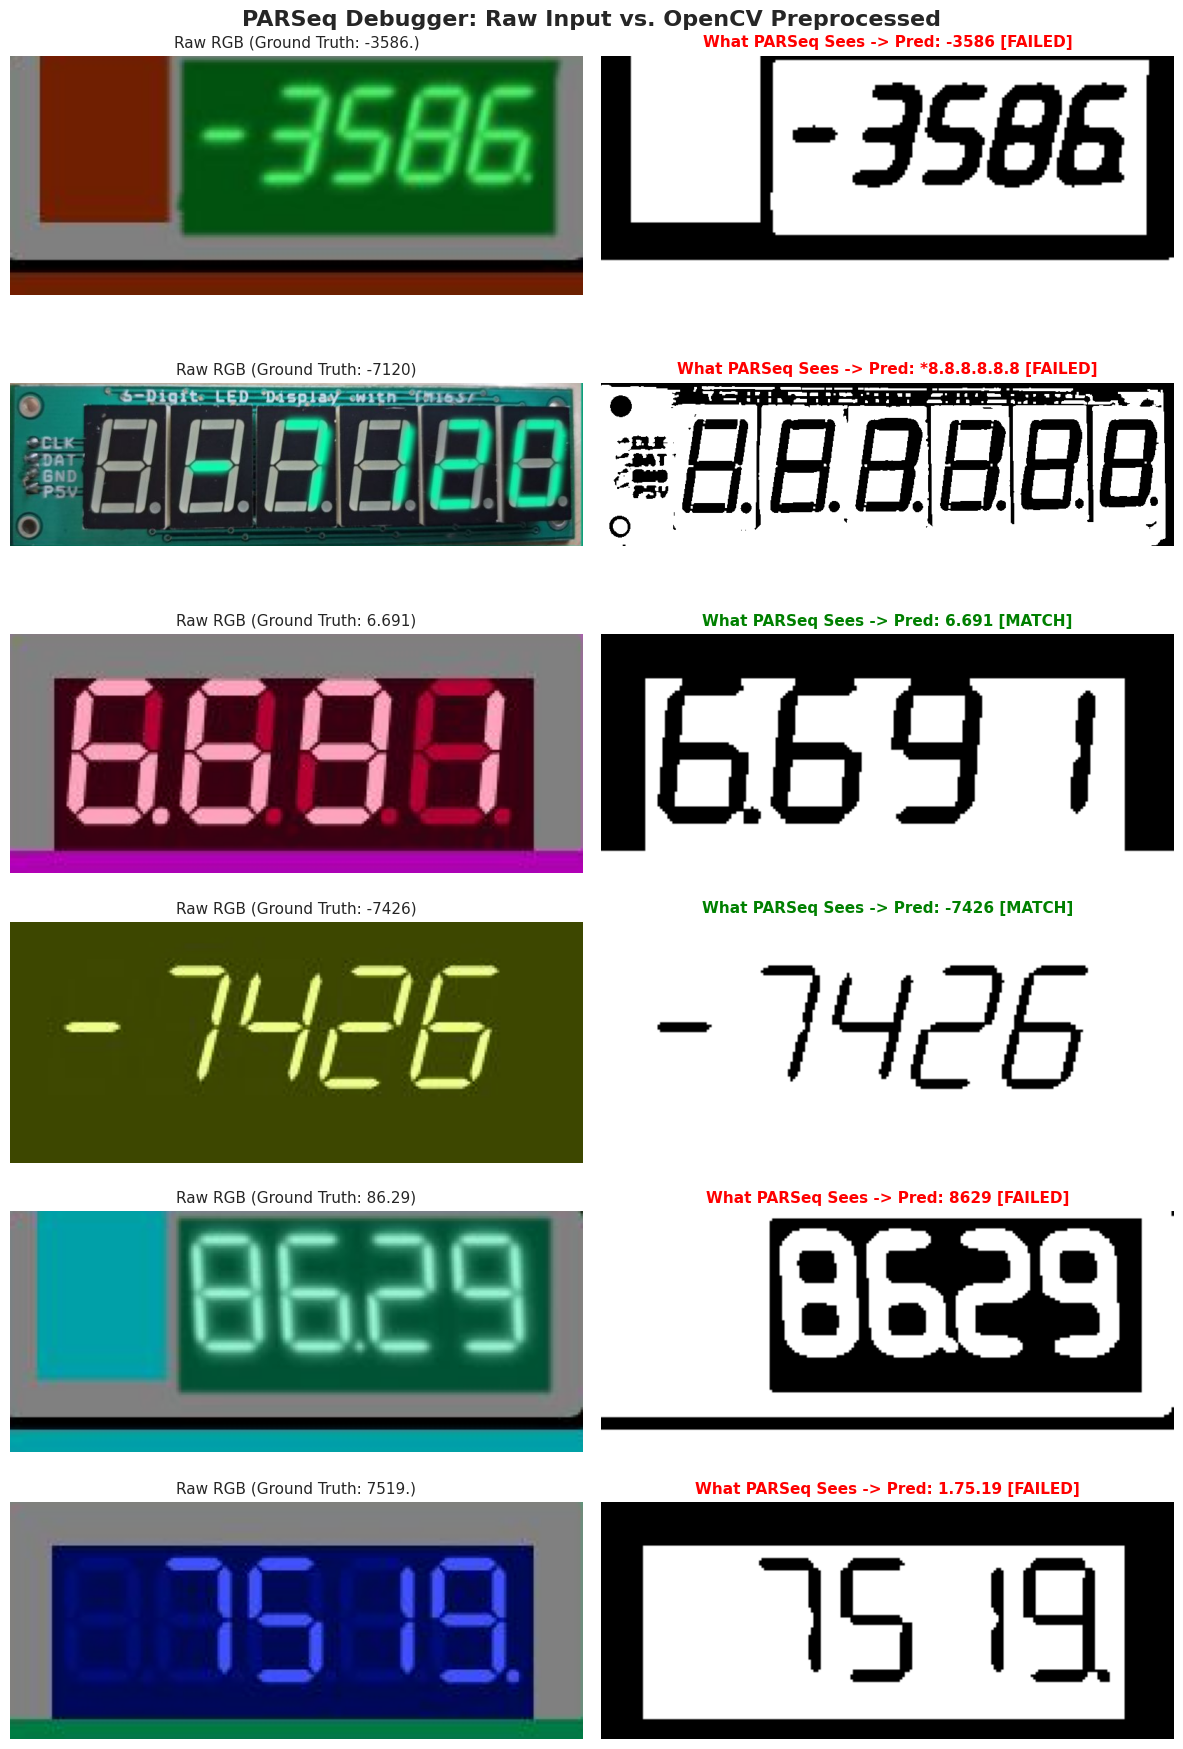

In [38]:
import os
import sys
import subprocess


def install_dependencies():
    missing = False
    try:
        import pytorch_lightning
        import timm
    except ImportError:
        missing = True

    if missing:
        print("Installing missing dependencies for PARSeq (pytorch-lightning, timm)...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pytorch-lightning", "timm"])
        print("Dependencies installed successfully!")

install_dependencies()

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset
from torchvision import transforms
from PIL import Image
import random

# 1. The OpenCV Preprocessing Function
def apply_opencv_preprocessing(pil_img):
    img_cv = np.array(pil_img.convert('L'))
    _, thresh = cv2.threshold(img_cv, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if np.mean(thresh) > 127:
        thresh = cv2.bitwise_not(thresh)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    final_img = cv2.bitwise_not(closed)

    return Image.fromarray(cv2.cvtColor(final_img, cv2.COLOR_GRAY2RGB))

# 2. PARSeq Wrapper
class PARSeqWrapper:
    def __init__(self):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = torch.hub.load('baudm/parseq', 'parseq', pretrained=True, verbose=False).eval().to(self.device)
        self.transform = transforms.Compose([
            transforms.Resize((32, 128), transforms.InterpolationMode.BICUBIC),
            transforms.ToTensor(), transforms.Normalize(0.5, 0.5)
        ])
    def predict(self, clean_image):
        with torch.no_grad():
            outputs = self.model(self.transform(clean_image).unsqueeze(0).to(self.device))
            label, _ = self.model.tokenizer.decode(outputs.softmax(-1))
        return label[0].strip() if label else ""

# 3. Execution & Plotting
print("Loading Model and Data...")
parseq = PARSeqWrapper()
dataset = load_dataset("parquet", data_files=drive_path, split="train")

# Pick 6 random images to visualize
random.seed(42) # Set seed for reproducible results
sample_indices = random.sample(range(50), 6)

fig, axes = plt.subplots(6, 2, figsize=(12, 18))
fig.suptitle("PARSeq Debugger: Raw Input vs. OpenCV Preprocessed", fontsize=16, fontweight='bold', y=0.98)

for row, idx in enumerate(sample_indices):
    raw_img = dataset[idx]['image']
    truth = str(dataset[idx]['text'])

    # Preprocess and Predict
    clean_img = apply_opencv_preprocessing(raw_img)
    prediction = parseq.predict(clean_img)

    # Determine Success
    is_match = truth.strip() == prediction.strip()
    color = 'green' if is_match else 'red'
    status = "MATCH" if is_match else "FAILED"

    # Plot Raw
    axes[row, 0].imshow(raw_img)
    axes[row, 0].set_title(f"Raw RGB (Ground Truth: {truth})", fontsize=11)
    axes[row, 0].axis('off')

    # Plot Preprocessed + Prediction
    axes[row, 1].imshow(clean_img)
    axes[row, 1].set_title(f"What PARSeq Sees -> Pred: {prediction} [{status}]", fontsize=11, color=color, fontweight='bold')
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()